# 位置情報は緯度経度で距離感を加味したいな！
# validationデータの切り方も重要か？

★実行環境の選択

In [10]:
# VSCodeの場合
edi_flg = 1
# Googlre Colabの場合
# edi_flg = 0

In [11]:
if edi_flg == 0:
  # GoogleColabにGitHubリポジトリをクローンする用
  %cd /content/My_Python_project

  from google.colab import auth
  auth.authenticate_user()
  !git clone https://github.com/keiseki-eng/My_Python_project
  !git pull origin main



In [12]:
# import sys
# !{sys.executable} -m pip install ipykernel

In [13]:
import os
import sys
import yaml
import pandas as pd
import numpy as np
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
import japanize_matplotlib

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, KFold

# srcディレクトリをPythonの検索パスに追加
sys.path.append("/home/keiseki/JR_train_snow/30.src")

# validation.pyからsplit_timeを読み込み
from utils.validation import split_time

In [14]:
if edi_flg == 0:
  from google.colab import drive
  drive.mount('/content/drive')

In [15]:
import warnings
warnings.filterwarnings(
    "ignore",
    category=pd.errors.PerformanceWarning
)

## 01.config読み込み

In [16]:
# VSCode用
if edi_flg==1:
  conf_path = os.path.join( '../00.config/config.yaml')
  path_set = os.path.join('../00.config/path.yaml')
  with open(conf_path, 'r') as f:
    config = yaml.safe_load(f)
  with open(path_set, 'r') as f:
    path_config = yaml.safe_load(f)

# GoogleColab用
elif edi_flg==0:
  conf_path = "My_Python_project/config/config.yaml"
  path_set = "My_Python_project/config/path.yaml"
  with open(conf_path, "r") as f:
    config = yaml.safe_load(f)
  with open(path_set, "r") as f:
    path_config = yaml.safe_load(f)

In [17]:
# 定義した特徴量リストを読み込み
feature_list = config['FEATURE']['FEATURE_LIST']
# カテゴリカルカラムのリストを定義
categorical_cols = config['FEATURE']['CATEGORICAL_COLS']

# 気象データ分
locations = config["WEATHER_FEATURE"]["locations"]
variables = config["WEATHER_FEATURE"]["variables"]
hours = config["WEATHER_FEATURE"]["hours"]
w_categories = config["WEATHER_CATEGORY"]["WEATHER_CATEGORY_LIST"]

# 気象データの特徴量リストを作成
weather_feature_cols = [
    f"{location}_{variable}_{hour}"
    for location in locations
    for variable in variables
    for hour in hours
]
weather_categorical_cols = [
    f"{location}_{w_category}_{hour}"
    for location in locations
    for w_category in w_categories
    for hour in hours
]

# 積雪計データ分
snow_locations = config["SNOW_FEATURE"]["locations"]
snow_variables = config["SNOW_FEATURE"]["variables"]
snow_statistics = config["SNOW_FEATURE"]["statistics"]
snow_time_zones = config["SNOW_FEATURE"]["time_zones"]
snow_categories = config["SNOW_CATEGORY"]["SNOW_CATEGORY_LIST"]

# 積雪計データの特徴量リストを作成
snow_feature_cols = [
    f"{location}_{variable}_{statistic}_{time_zone}"
    for location in snow_locations
    for variable in snow_variables
    for statistic in snow_statistics
    for time_zone in snow_time_zones
]
snow_categorical_cols = [
    f"{location}_{snow_category}_{time_zone}"
    for location in snow_locations
    for snow_category in snow_categories
    for time_zone in snow_time_zones
]

# 通常の特徴量リストに気象データ分を追加
feature_list += weather_feature_cols
categorical_cols += weather_categorical_cols
# 通常の特徴量リストに積雪計データ分を追加
feature_list += snow_feature_cols
categorical_cols += snow_categorical_cols

# validationの分割日を設定
split_date = config["split_date"]

In [18]:
# 学習データ、テストデータの読み込み
train_data_path = path_config['INTERIUM_PATH']['train_data']
test_data_path = path_config['INTERIUM_PATH']['test_data']

df_train = pd.read_pickle(train_data_path)
df_test = pd.read_pickle(test_data_path)


## addr1+2に対し、ターゲットエンコーディングを実装

In [19]:
# df_train, addr1_2_global_mean = target_encode_oof(
#     df_train,
#     col="addr1+2",
#     target="money_room",
#     n_splits=5,
#     smoothing=20
# )


## interaction特徴量を追加

## 05.train/valid 分割　＆　target加工

In [20]:
# feature_listに存在しないカラムがあれば、NaNで追加
fix_list = feature_list + ["年月日", "合計"]
df_train = df_train.reindex(columns=fix_list)
# 時系列分析のため、train_test_splitではなくsplit_timeを使用
X_train, X_valid, y_train, y_valid, = split_time(df_train, split_col="年月日", target_col="合計", split_date=split_date)
# ランダム分割の場合
# X_train, X_valid, y_train, y_valid, = train_test_split(df_train, df_train["合計"], test_size=0.2, random_state=42)


train: 2016-01-19 00:00:00 ～ 2016-12-09 00:00:00
valid: 2016-12-10 00:00:00 ～ 2016-12-31 00:00:00
train件数: 14368
valid件数: 971


In [21]:
print("train:")
print(X_train["年月日"].min(), "～", X_train["年月日"].max())

print("valid:")
print(X_valid["年月日"].min(), "～", X_valid["年月日"].max())

train:
2016-01-19 00:00:00 ～ 2016-12-09 00:00:00
valid:
2016-12-10 00:00:00 ～ 2016-12-31 00:00:00


## 07.モデル学習

In [22]:
def wmae_eval(preds, train_data):
    y_true = train_data.get_label()

    # コンペ指定の重み
    weights = np.abs(y_true) * 1e4 + 1

    wmae = np.sum(weights * np.abs(y_true - preds)) / np.sum(weights)

    return "WMAE", wmae, False

In [23]:
# 学習データの前処理:特徴量リストに限定
X_train = X_train[feature_list].copy()
X_valid = X_valid[feature_list].copy()
    
# ：object型の列をcategoryへ
cat_cols = [c for c in categorical_cols if c in X_train.columns]
# 明示的にobject型の全列もcategoryに変換（未指定のカテゴリ列がある場合に備えて）
obj_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

for df in [X_train, X_valid, df_test]:
    cols = sorted(set(cat_cols + obj_cols).intersection(df.columns))
    if cols:
        df[cols] = df[cols].astype("category")

/tmp/ipykernel_1546/4221972066.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = X_train.select_dtypes(include=["object"]).columns.tolist()


In [24]:
for col in [c for c in X_train.columns if "日照時間" in c]:
    X_train[col] = pd.to_numeric(X_train[col], errors="coerce")
    X_valid[col] = pd.to_numeric(X_valid[col], errors="coerce")


In [25]:
# LightGBM のパラメータ設定
params = config['MODEL_PARAMS']

# LightGBM のデータセットを作成
lgb_train = lgb.Dataset(
    X_train,
    y_train,
    categorical_feature=categorical_cols
)


lgb_test = lgb.Dataset(
    X_valid,
    y_valid,
    reference=lgb_train,
    categorical_feature=categorical_cols
)


# モデルの学習
model = lgb.train(
    params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_train, lgb_test],
    feval=wmae_eval,
    callbacks=[
        lgb.early_stopping(100)
    ]
)

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[52]	training's WMAE: 0.00407085	valid_1's WMAE: 0.000463849


## 08.評価

特徴量の重要度


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

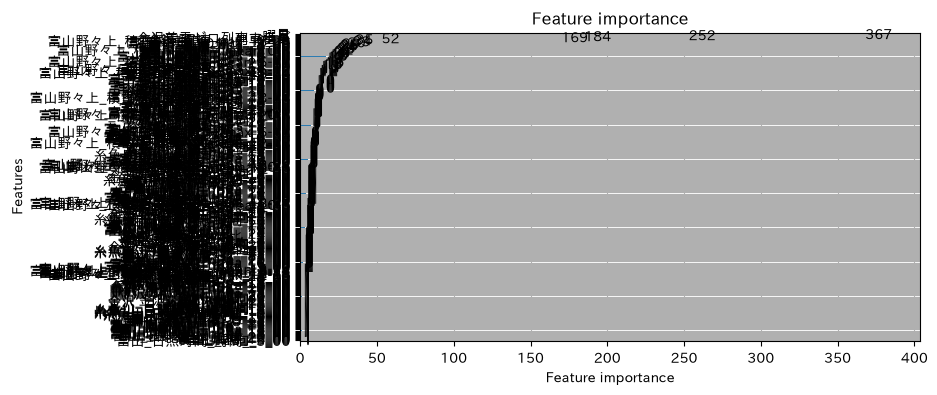

In [26]:
# 検証データで予測
y_pred = model.predict(X_valid , num_iteration=model.best_iteration)


# 特徴量の重要度
print("特徴量の重要度")
lgb.plot_importance(model, figsize=(8,4))


## 09.可視化（importance SHAP）

In [27]:

# import lightgbm as lgb
# from sklearn.model_selection import GridSearchCV

# # パラメータの探索範囲を指定
# param_grid = {
#     'num_leaves': [20, 30, 40],
#     'learning_rate': [0.01, 0.1, 0.5],
#     'max_depth': [5, 10]
# }




# # グリッドサーチCV
# gsearch = GridSearchCV(gbm, param_grid, cv=5) #cvは交差検証の回数

# # データを学習
# gsearch.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)])



# # 最適なパラメータとスコアを表示
# print('Best parameters found by grid search are:', gsearch.best_params_)
# print('Best score:', gsearch.best_score_)


In [28]:
# # パラメータの辞書を結合
# best_params = {**params, **gsearch.best_params_}

# # 最適パラメータでモデルを再学習
# model = lgb.LGBMClassifier(**best_params)
# model.fit(X_train, y_train)

In [29]:
#SHAP値の取得
explainer = shap.TreeExplainer(model=model)#SHAP値を取得するためのモデル作成
shap_values = explainer.shap_values(X=X_valid)#説明変数それぞれの値のSHAP値を取得する

# print(shap_values)
# print(shap_values.shape)


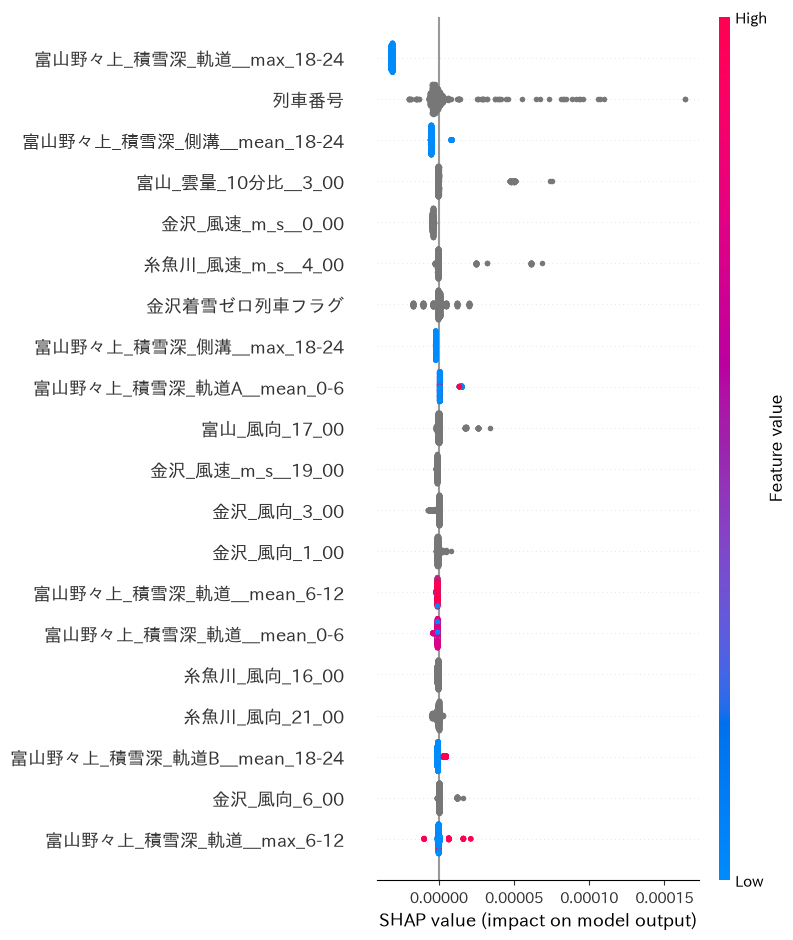

In [30]:

# 変数別の影響度の可視化
shap.initjs()
# shap.summary_plot(shap_values, X_valid, plot_type="bar", show=False)
shap.summary_plot(shap_values, X_valid, show=False)


# 0番目のデータポイントを再選択
i = 0
single_observation = X_valid.iloc[i:i+1,:]


#print(single_observation)


# Explainerを使って説明を再計算
# single_shap_values = explainer(single_observation)

# waterfallプロットの生成
# shap.waterfall_plot(single_shap_values[0])

## 10.推論、提出

## 提出用データの作成

In [31]:
# 特徴量の選定
# feature_listに存在しないカラムがあれば、NaNで追加
df_test_p = df_test.reindex(columns=feature_list)

for col in [c for c in X_train.columns if "日照時間" in c]:
    df_test_p[col] = pd.to_numeric(df_test_p[col], errors="coerce")


# 予測
y_pred  = model.predict(df_test_p)
# y_scores_submit = np.clip(y_pred, 6e6, 1e8)

print(y_pred)

[ 1.81827625e-04  1.51995165e-05  1.80976805e-05 ... -4.12226523e-06
 -5.13605061e-06 -2.88530329e-06]


In [32]:

#提出用csvの作成
df_scores_submit = pd.DataFrame(y_pred)

# df_submit = pd.concat([df_test["id"], df_scores_submit], axis=1)
# df_scores_submit.index = df_scores_submit.index + 1
df_scores_submit.to_csv("submit.csv", index=True, header=False)




## 誤差要因分析

In [33]:
import numpy as np
import pandas as pd

# Validデータを予測
y_pred = model.predict(X_valid)

# 誤差分析用DataFrame
error_df = X_valid.copy()

error_df["実測値"] = y_valid.values
error_df["予測値"] = y_pred

# 符号付き誤差
# プラス：実測 > 予測 → 過小予測
# マイナス：実測 < 予測 → 過大予測
error_df["誤差"] = error_df["実測値"] - error_df["予測値"]

# 絶対誤差
error_df["絶対誤差"] = np.abs(error_df["誤差"])

# コンテスト評価と同じ重み
error_df["重み"] = np.abs(error_df["実測値"]) * 1e4 + 1

# WMAE用の加重絶対誤差
error_df["加重絶対誤差"] = (
    error_df["重み"] * error_df["絶対誤差"]
)

print(f"Valid件数: {len(error_df):,}")
print(f"Valid MAE : {error_df['絶対誤差'].mean():.6f}")
print(
    f"Valid WMAE: "
    f"{error_df['加重絶対誤差'].sum() / error_df['重み'].sum():.9f}"
)

print(
    error_df[
        ["実測値", "予測値", "誤差", "絶対誤差"]
    ]
    .describe()
)
# 誤差が大きい順に確認
error_df.sort_values(
    "絶対誤差",
    ascending=False
)[
    ["実測値", "予測値", "誤差", "絶対誤差"]
].head(20)

Valid件数: 971
Valid MAE : 0.000041
Valid WMAE: 0.000463849
              実測値           予測値            誤差          絶対誤差
count  971.000000  9.710000e+02  9.710000e+02  9.710000e+02
mean     0.000027  1.008287e-05  1.681989e-05  4.074901e-05
std      0.000235  3.087784e-05  2.338166e-04  2.308489e-04
min      0.000000 -4.311773e-05 -3.215728e-04  1.422469e-08
25%      0.000000 -2.926048e-06 -8.062409e-06  1.798227e-06
50%      0.000000  7.916939e-07 -6.940030e-07  4.577030e-06
75%      0.000000  8.071373e-06  3.327966e-06  1.155010e-05
max      0.003791  3.215728e-04  3.734922e-03  3.734922e-03


,実測値,予測値,誤差,絶対誤差
14610,0.003791,5.600463e-05,0.003735,0.003735
14646,0.002940,7.772513e-07,0.002940,0.002940
14613,0.002692,-3.622175e-05,0.002728,0.002728
14632,0.002555,-1.699924e-06,0.002557,0.002557
14615,0.002224,3.215728e-04,0.001903,0.001903
14647,0.001534,3.675056e-05,0.001497,0.001497
14628,0.001350,3.675056e-05,0.001313,0.001313
14630,0.001255,4.763950e-06,0.001250,0.001250
14621,0.001195,-4.773323e-06,0.001199,0.001199
14622,0.000982,-1.303320e-06,0.000984,0.000984


In [34]:
error_df["実測値_bin"] = pd.cut(
    error_df["実測値"],
    bins=[-np.inf, 0, 0.01, 0.03, 0.05, 0.1, 0.2, np.inf]
)

summary = error_df.groupby(
    "実測値_bin",
    observed=True
).agg(
    件数=("実測値", "size"),
    平均実測=("実測値", "mean"),
    平均予測=("予測値", "mean"),
    MAE=("絶対誤差", "mean"),
    WMAE=("加重絶対誤差", "sum")
)

summary["WMAE"] = (
    summary["WMAE"]
    / error_df.groupby("実測値_bin", observed=True)["重み"].sum()
)

print(summary)

              件数      平均実測      平均予測       MAE      WMAE
実測値_bin                                                 
(-inf, 0.0]  953  0.000000  0.000010  0.000015  0.000015
(0.0, 0.01]   18  0.001451  0.000021  0.001430  0.001997


In [35]:
train_summary = error_df.groupby("列車番号").agg(
    件数=("実測値", "size"),
    平均実測=("実測値", "mean"),
    平均予測=("予測値", "mean"),
    MAE=("絶対誤差", "mean"),
    加重誤差=("加重絶対誤差", "sum"),
    重み=("重み", "sum")
)

train_summary["WMAE"] = (
    train_summary["加重誤差"]
    / train_summary["重み"]
)

print(
    train_summary
    .sort_values("WMAE", ascending=False)
    .head(30)
)

       件数      平均実測      平均予測       MAE      加重誤差        重み      WMAE
列車番号                                                                 
9536E  23  0.000165  0.000045  0.000205  0.146309  60.90927  0.002402
3502E  23  0.000128  0.000005  0.000136  0.089565  52.40367  0.001709
554E   44  0.000061  0.000004  0.000071  0.076572  70.91817  0.001080
3500E  23  0.000097  0.000136  0.000205  0.047025  45.24091  0.001039
574E   44  0.000058  0.000007  0.000071  0.068454  69.54972  0.000984
562E   44  0.000035  0.000010  0.000048  0.025075  59.33896  0.000423
578E   44  0.000031  0.000010  0.000044  0.019643  57.49566  0.000342
558E   44  0.000029  0.000008  0.000041  0.017503  56.54784  0.000310
566E   44  0.000027  0.000004  0.000036  0.015903  55.94695  0.000284
590E   44  0.000022  0.000009  0.000036  0.011232  53.82470  0.000209
570E   44  0.000022  0.000007  0.000035  0.010653  53.54105  0.000199
568E   44  0.000021  0.000005  0.000030  0.010133  53.40666  0.000190
564E   44  0.000020 

In [36]:
train_analysis = error_df.groupby("列車番号").agg(
    件数=("実測値", "size"),
    着雪発生件数=("実測値", lambda x: (x > 0).sum()),
    平均実測=("実測値", "mean"),
    最大実測=("実測値", "max"),
    MAE=("絶対誤差", "mean"),
)

train_analysis["着雪発生率"] = (
    train_analysis["着雪発生件数"]
    / train_analysis["件数"]
)

train_analysis = train_analysis.sort_values(
    "着雪発生率",
    ascending=False
)

print(train_analysis)

       件数  着雪発生件数      平均実測      最大実測       MAE     着雪発生率
列車番号                                                     
3500E  23       1  0.000097  0.002224  0.000205  0.043478
3502E  23       1  0.000128  0.002940  0.000136  0.043478
9536E  23       1  0.000165  0.003791  0.000205  0.043478
556E   44       1  0.000014  0.000620  0.000027  0.022727
552E   44       1  0.000013  0.000594  0.000023  0.022727
564E   44       1  0.000020  0.000888  0.000028  0.022727
570E   44       1  0.000022  0.000954  0.000035  0.022727
568E   44       1  0.000021  0.000941  0.000030  0.022727
566E   44       1  0.000027  0.001195  0.000036  0.022727
560E   44       1  0.000008  0.000345  0.000018  0.022727
562E   44       1  0.000035  0.001534  0.000048  0.022727
558E   44       1  0.000029  0.001255  0.000041  0.022727
554E   44       1  0.000061  0.002692  0.000071  0.022727
572E   44       1  0.000015  0.000663  0.000025  0.022727
574E   44       1  0.000058  0.002555  0.000071  0.022727
578E   44     

In [37]:
df_train.groupby("列車番号").agg(
    件数=("合計", "size"),
    着雪発生件数=("合計", lambda x: (x > 0).sum()),
    平均実測=("合計", "mean"),
    最大実測=("合計", "max"),
    MAE=("合計", "mean"),
).sort_values("着雪発生件数", ascending=False)

,件数,着雪発生件数,平均実測,最大実測,MAE
列車番号,,,,,
3500E,349,7,0.000197,0.020128,0.000197
556E,696,7,0.000102,0.037332,0.000102
558E,696,7,0.000131,0.049420,0.000131
560E,696,6,0.000023,0.003466,0.000023
554E,696,6,0.000058,0.018141,0.000058
590E,696,6,0.000030,0.014888,0.000030
564E,696,6,0.000035,0.013553,0.000035
9536E,349,5,0.000089,0.011894,0.000089
572E,696,5,0.000013,0.005138,0.000013


In [38]:
station_summary = error_df.groupby("駅名").agg(
    件数=("実測値", "size"),
    平均実測=("実測値", "mean"),
    平均予測=("予測値", "mean"),
    MAE=("絶対誤差", "mean"),
    加重誤差=("加重絶対誤差", "sum"),
    重み=("重み", "sum")
)

station_summary["WMAE"] = (
    station_summary["加重誤差"]
    / station_summary["重み"]
)

print(
    station_summary.sort_values(
        "WMAE",
        ascending=False
    )
)

KeyError: '駅名'

In [ ]:
error_df.sort_values(
    "絶対誤差",
    ascending=False
).head(30)